# Machine Learning Project - Dataset Description and Evaluation Protocol 

## Dataset 

The prosed dataset is a custom selection of data from multiple databases of the 
National Forest Inventory of Germany (engl.: NFI, germ.: BWI). The NFI Germany 
is fixed in German law; providing information on the state of Germany Forests 
and Forestry one a decade. After the reuinon of the German state three NFIs 
have been conducted: 2002, 2012 and 2022. The dataset includes data from the
first and second NFI (years 2002-2012).  

The code to extract the databses and generate a custom dataset found in this [git repository](https://github.com/hansendav/UBS-ML-24/). 

In [38]:
from PIL import Image
from IPython.display import display

### NFI Germany - What data is collected and how?
- **The NFI is based on a regular grid of varying density (depending on the region)**
    - The base density is 4x4km up to 2x2km; 
    - Vertices are unique accross Germany; 
    - At each vertex 4 samplings are conducted at the corners of a 150x150m square with the position of its lower left corner being equal to the grid vertices. 
    - At each sampling point tree and forest stand parameters are measured and modelled using different techniques.

- **The NFI has fixed grid which allows to compare the state of forests in the selected 10 year cycles** 
- **Various types of data are collected during the process on different levels** (Single tree level, sample plot level, vertex level)
- The data allows to work on multiple machine learning tasks from which the most interesting ones are tree species classification and growth prediction (in various forms e.g. height, biomass). In this project I will work on the **classification task**.  

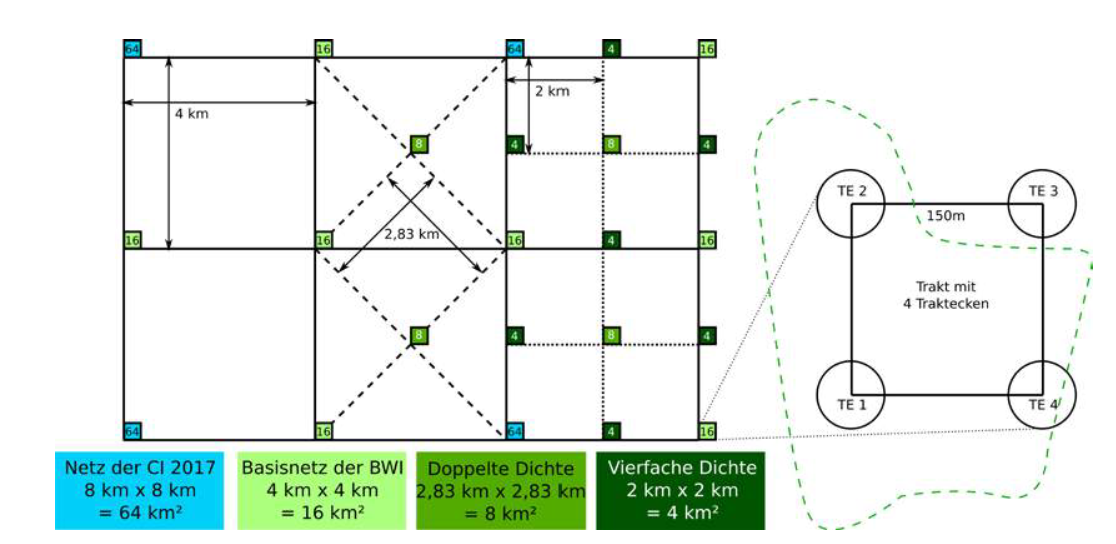

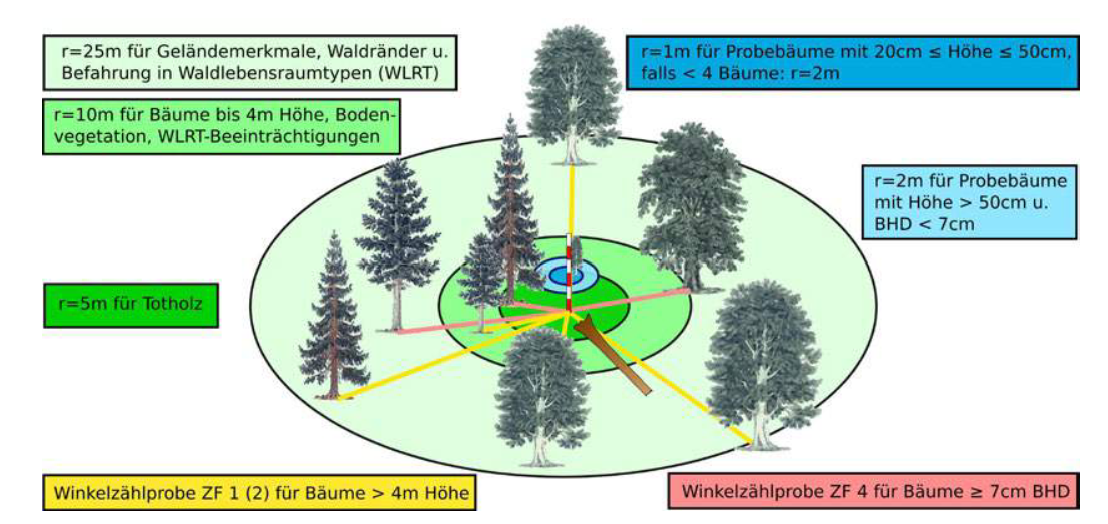

In [44]:
display(Image.open('./imgs/grid_info.png'))
display(Image.open('./imgs/sample.png'))

| Feature         | Description | Type |
|:----------------|:------------|------:|
| Tnr             |'Traktnummer': Identifier of grid points **unique across Germany**. | Numerical/Identifier |
| Enr             |'Eckennummer: Identifer of the sampling plot **1-4 unique for each grid point** | Numerical identifier |
| Bnr             |'Baumnummer: Treenumber **unique within each sampling plot** | Numerical identifier | 
| Av              |**REMOVE THIS**
| Ba              |'Baumart: Tree species | Nominal **TARGET**|
| Al_ba           |'Baumalter: Tree age [$a$] | Discrete |
| Bs              |'Bestandesschicht': Canopy layer | Nominal |
| Bhd             |'Brusthöhendurchmesser: Diamerter at breast height [$mm$] | Continuous |
| Hoehe           |'Höhe': Height [$dm$ | Continuous |
| D7              |**REMOVE THIS** (not always measured) |
| D03             |**REMOVE THIS** (not always measured) |
| G               |'Grundfläche': Basal area [$m^2$] | Continuous | 
| VolR            |'Volumen Vorratsfestmeter': Volume with bark [$m^3$] | Continuous |
| VolR_FAO        |'Volumen Vorratsfestmeter - FAO': Volume with bark [$m^3$] | Continuous |
| VolE            |'Volumen Erntefestmeter': Volume without bark [$m^3] | Continuous |
| vVolE           |'verwendbarer Erntefestmeter': Volume without bark sawwood ready [$m^3$] | Continuous |
| N_ha            |'Stammzahl je Hektar': Number of trees per hectar | Continuous |
| Stf             |'Standfläche': 'Canopy footprint' [$m^2$] | Continuous |
| StfM            |**REMOVE THIS** Normalized version of Stf (to fit 1ha) |
| Bhdst1          |'Brusthöhendurchmesserstufe - 1cm': DBH in 1cm bins | Discrete |
| Bhdst5          |'Brusthöhendurchmesserstufe - 5cm': DBH in 5cm bins |Discrete |
| Alkl5           |'Altersklasse Jahresstufe - 5': Age in 5 year bins | Discrete |
| GrGr2           |'Größenklassenstufe': Height binning | Nominal (DBH and Height mixed) |
| jSchael_x       |'Frische Schälschäden': New (<12 months) damages bark peeling | Discrete / Ordinal |
| Biom_o          |'Biomasse oberirdisch': Aboveground biomass [$kg$] | Continuous |
| Biom_u          |'Biomasse unterirdisch': Belowground biomass [$kg$] |Continuous |
| Biov_o          |'Biomasse überirdisch' : Aboveground biomass[$m^3$] | Continuous |
| Gexp            |'Geländexposition': Aspect [$gon$] | Continuous/Discrete
| GExpKl4         |'Geländeexpositionsklasse': Aspect in classes (4) | Discrete |
| GExpKl8         |'Geländeexpositionsklasse: Aspect in classes (8) | Discrete |
| Gform           |'Geländeform': Terrain | Nominal |
| Gneig           |'Geländeneigung': Slope [$\%$] | Discrete / Continuous |
| GneigKl5        |'Geländeneigunsklassen - 5': Slope categories (5) [$\%$] | Discrete |
| natHoe          |'natürliche Höhenstufe': natural height class | Ordinal |
| potNatWg        |'potenzielle natürliche Waldgesellschaft': potential natural forest community | Nominal |
| HoeheNN         |'Höhe NN': Height above German normal height [$m$] | Continuous |
| hnnSt100        |'Höhenstufe 100': Height in 100m bins | Discrete / Ordinal
| hnnSt250        |'Höhenstufe 250': Height in 250m bins | Discrete / Ordinal
| Zaun            |'Zaun': Fenced (Yes/No) | Discrete / Ordinal 
| Be              |'Betriebsart': Operation catgeory | Nominal |
| NatNaeheHaupt   |'Ermittelte Naturnähe (durch Hauptbestand WZP-4)': Estimated closeness to nature (using the main canopy layer) | Nominal / Ordinal |
| NatNaeheLT7cm   |'Ermittelte Natunähe (bis Größeklasse 6) Probekreise 1-4m: Estimated closeness to nature (up to height class 6 and sample radii 1-4m) | Nominal / Ordinal |
| ForestType      |European Forest Type | Nominal |
| RAN             |'Anzahl Wald und Bestandesränder': Number of forest/foreststand edges | Discrete | 
| Situation       |'Besondere Bestandessituation': Special forest stand situation | Discrete |
| TOT             |'Anzahl Totholzstücke': Pieces of deadwood | Discrete | 
| Kaefer          |'Käferlöcher': Bettle boreholes (Yes / No) | Discrete / Ordinal |
| jSchael_y       |**REMOVE THIS DOUBLE ENTRY** |
| aeSchael        |'Ältere Schälschäden': Older peeling damages (> 12 months) (Yes / No) | Discrete / Ordinal |
| Bkl             |'Baumklasse': Tree social class | Ordinal |
| Ast             |'Astung': **ADD ENGLISH DESCRIPTION** | Nominal |
| tot             |'Zeitpunkt tot': Time of death (**USE FOR FILTERING**) | Nominal | 
| AnzSchad        |'Anzahl Schäden am Baum bis 8': Number of damages (max 8) | Discrete |
| Ruecke          |'Rücke- oder Fällschäden': Damages due to felling or logging (Yes / No) | Discrete / Ordinal |
| Specht          |'Specht': Woodpecker (Yes / No) | Discrete / Ordinal |
| Pilz            |'Pilzkonsolen': Mushroom (Yes / No) | Discre / Ordinal |
| Harz            |'Harz': Resin (Yes / No) | Discrete / Ordinal | 
| BestockAb       |'Bestockungsaufbau': Forest stories | Nominal |
| Al_baDiff       | Difference 2012-2002 Al_ba | Continuous |
| BhdDiff         | Difference 2012-2002 BhdDiff | Continuous |
| HoeheDiff       | Difference 2012-2002 Hoehe | Continuous |
| GDiff           | Difference 2012-2002 G | Continuous |
| VolRDiff        | Difference 2012-2002 VolR | Continuous |
| VolEDiff        | Difference 2012-2002 VolE | Continuous |
| vVolEDiff       | Difference 2012-2002 vVolE | Continuous |
| Biom_oDiff      | Difference 2012-2002 Biom_o | Continuous |
| Biom_uDiff      | Difference 2012-2002 Biom_u | Continuous |
| Biov_oDiff      | Difference 2012-2002 Biov_o | Continuous |
| LAND            |**REMOVE THIS**
| SOEH_NR         |**REMOVE THIS**
| SOEH_KRZ        |**REMOVE THIS**
| SOEH_VAR        |**REMOVE THIS**
| BODTYP          |'Bodentyp': Soiltype | Nominal |
| NAEHR           |'Nährstoffkraft': Nutritive power | Nominal / Ordinal 
| WASSER          |'Wasserhaushaltstufe': Water budget bin | Nominal |
| NumHTypes       |'Anzahl Horizonttypen': Number of soil horizont types | Continuous |
| nfk_30          |'Feldkapazität 30cm': Water holding capacity in 30cm | Continuous |
| nfk_60          |'Feldkapazität 30cm': Water holding capacity in 30cm | Continuous |
| nfk_80          |'Feldkapazität 30cm': Water holding capacity in 30cm | Continuous |
| nfk_90          |'Feldkapazität 30cm': Water holding capacity in 30cm | Continuous |
| nfk_100         |'Feldkapazität 30cm': Water holding capacity in 30cm | Continuous |
| nfk_160         |'Feldkapazität 30cm': Water holding capacity in 30cm | Continuous |
| bl              |**REMOVE THIS** |
| year_first      |**REMOVE THIS** |
| year_last       |**REMOVE THIS** |
| bio_1           |Annual mean temperature (2001-2010) as the mean of the monthly temperatures in [$°C$] | Continuous |
| bio_2           |Mean diurnal range (2001-2010) as the mean of monthly (max temp - min temp) in [$°C$] | Continuous |
| bio_3           |Isothermality (2001-2010) in [$°C$] | Continuous |
| bio_4           |Temperature seasonality (2001-2010) in [$°C$] | Continuous |
| bio_5           |Max temperature of warmest month (2001-2010) in [$°C$] | Continuous |
| bio_6           |Min temperature of coldest month (2001-2010) in [$°C$] | Continuous |
| bio_7           |Temperature annual range (2001-2010) (bio_5 - bio_6) in [$°C$] | Continuous |
| bio_8           |Mean temperature of wettest quarter (2001-2010) in [$°C$] | Continuous |
| bio_9           |Mean temperature of driest quarter (2001-2010) in [$°C$] | Continuous |
| bio_10          |Mean temperature of warmest quarter (2001-2010) in [$°C$] | Continuous |
| bio_11          |Mean temperature of coldest quarter (2001-2010) in [$°C$] | Continuous |
| bio_12          |Annual precipitation (2001-2010) in [$mm$] | Continuous |
| bio_13          |Precipitation of wettest month (2001-2010) in [$mm$] | Continuous |
| bio_14          |Precipitation of driest month (2001-2010) in [$mm$] | Continuous |
| bio_15          |Precipitation seasonality (2001-2010) in [$mm$] | Continuous |
| bio_16          |Precipitation of wettest quarter (2001-2010) in [$mm$] | Continuous |
| bio_17          |Precipitation of driest quarter (2001-2010) in [$mm$] | Continuous |
| bio_18          |Precipitation of warmest quarter (2001-2010) in [$mm$] | Continuous |
| bio_19          |Precipitation of coldest quarter (2001-2010) in [$mm$] | Continuous |

## Dataset postprocessing after generation

In [2]:
# Data handling and plotting
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
# Import dataset 
data = pd.read_csv('../datasets/ml_bwi_dataset.csv')

In [4]:
def filter_df_by_nodata_value(df, no_data_value, filter_type='any'):
    if isinstance(no_data_value, list):
        for value in no_data_value:
            df.replace(value, np.nan, inplace=True)
    else:
        df.replace(no_data_value, np.nan, inplace=True)
    df.dropna(how=filter_type, inplace=True)
    

In [5]:
# Filter rows that contain no data for any feature
filter_df_by_nodata_value(data, no_data_value=[-9999, -1], filter_type='any')

**Removing columns based on pre-selection**: To reduce the reduncancy/correlation of features. 

In [6]:
del_columns = [
    'Tnr', # Include for spatial information?
    'Enr', # Include for spatial information?
    'Bnr',
    'LAND', # Include for spatial information?
    'bl', # Redundant to 'Land'  
    'Av',
    'D7',
    'D03',
    'VolR_FAO',
    'StfM',
    'Bhdst1',
    'Bhdst5',
    'Alkl5',
    'jSchael_y',
    'GExpKl4',
    'GExpKl8',
    'GneigKl5',
    'hnnSt100',
    'hnnSt250',
    'NatNaeheLT7cm',
    'ForestType',
    'SOEH_NR',
    'SOEH_KRZ',
    'SOEH_VAR',
    'year_first',
    'year_last'
]

In [7]:
data.drop(columns=del_columns, inplace=True)

**Remove rows that contain negative growth estimation**

In [8]:
diff_columns = [col for col in data.columns if 'Diff' in col]
data = data[(data[diff_columns] < 0).any(axis=1)]

**Only select main tree species in Germany** 

In [9]:
species = [10, 20, 30, 40, 50, 100, 110, 11, 140, 141, 200]

In [10]:

data = data[data['Ba'].isin(species)]

In [11]:
# Transform oak and maple species into one category
data.loc[data['Ba'].isin([110, 11]), 'Ba'] = 110
data.loc[data['Ba'].isin([140, 141]), 'Ba'] = 140

In [12]:
data['Ba'].value_counts()

Ba
100    1455
20     1108
10     1045
110     205
140     131
30      127
200      88
50       54
40       11
Name: count, dtype: int64

In [13]:
# Filter dead trees 
data = data[data['tot'] == 0]

In [14]:
data.drop(columns=['tot'], inplace=True)

In [15]:
target = data['Ba']
features = data.drop('Ba', axis=1)

In [16]:
features.columns

Index(['Al_ba', 'Bs', 'Bhd', 'Hoehe', 'G', 'VolR', 'VolE', 'vVolE', 'N_ha',
       'Stf', 'GrGr2', 'jSchael_x', 'Biom_o', 'Biom_u', 'Biov_o', 'Gexp',
       'Gform', 'Gneig', 'natHoe', 'potNatWg', 'HoeheNN', 'Zaun', 'Be',
       'NatNaeheHaupt', 'RAN', 'Situation', 'TOT', 'Kaefer', 'aeSchael', 'Bkl',
       'Ast', 'AnzSchad', 'Ruecke', 'Specht', 'Pilz', 'Harz', 'BestockAb',
       'Al_baDiff', 'BhdDiff', 'HoeheDiff', 'GDiff', 'VolRDiff', 'VolEDiff',
       'vVolEDiff', 'Biom_oDiff', 'Biom_uDiff', 'Biov_oDiff', 'BODTYP',
       'NAEHR', 'WASSER', 'ADepth', 'NumHTypes', 'nfk_30', 'nfk_60', 'nfk_80',
       'nfk_90', 'nfk_100', 'nfk_160', 'bl', 'bio_1', 'bio_2', 'bio_3',
       'bio_4', 'bio_5', 'bio_6', 'bio_7', 'bio_8', 'bio_9', 'bio_10',
       'bio_11', 'bio_12', 'bio_13', 'bio_14', 'bio_15', 'bio_16', 'bio_17',
       'bio_18', 'bio_19'],
      dtype='object')

In [17]:
columns_to_drop = [
    'Bs', 'GrGr2', 'jSchael_x', 'Gform', 'natHoe', 'potNatWg', 'Zaun', 'Be', 'Ast', 'Ruecke', 'Specht', 'Pilz',
    'Harz', 'BestockAb', 'BODTYP', 'NAEHR', 'WASSER', 'bl'
]
features_continuous = features.drop(columns_to_drop, axis=1)

In [24]:
corr_mat = features_continuous.corr().stack().reset_index(name="correlation")

In [25]:
corr_mat

,level_0,level_1,correlation
0,Al_ba,Al_ba,1.000000
1,Al_ba,Bhd,0.633754
2,Al_ba,Hoehe,0.457066
3,Al_ba,G,0.580126
4,Al_ba,VolR,0.552278
...,...,...,...
3595,bio_19,bio_15,-0.104032
3596,bio_19,bio_16,0.683442
3597,bio_19,bio_17,0.918773
3598,bio_19,bio_18,0.584816


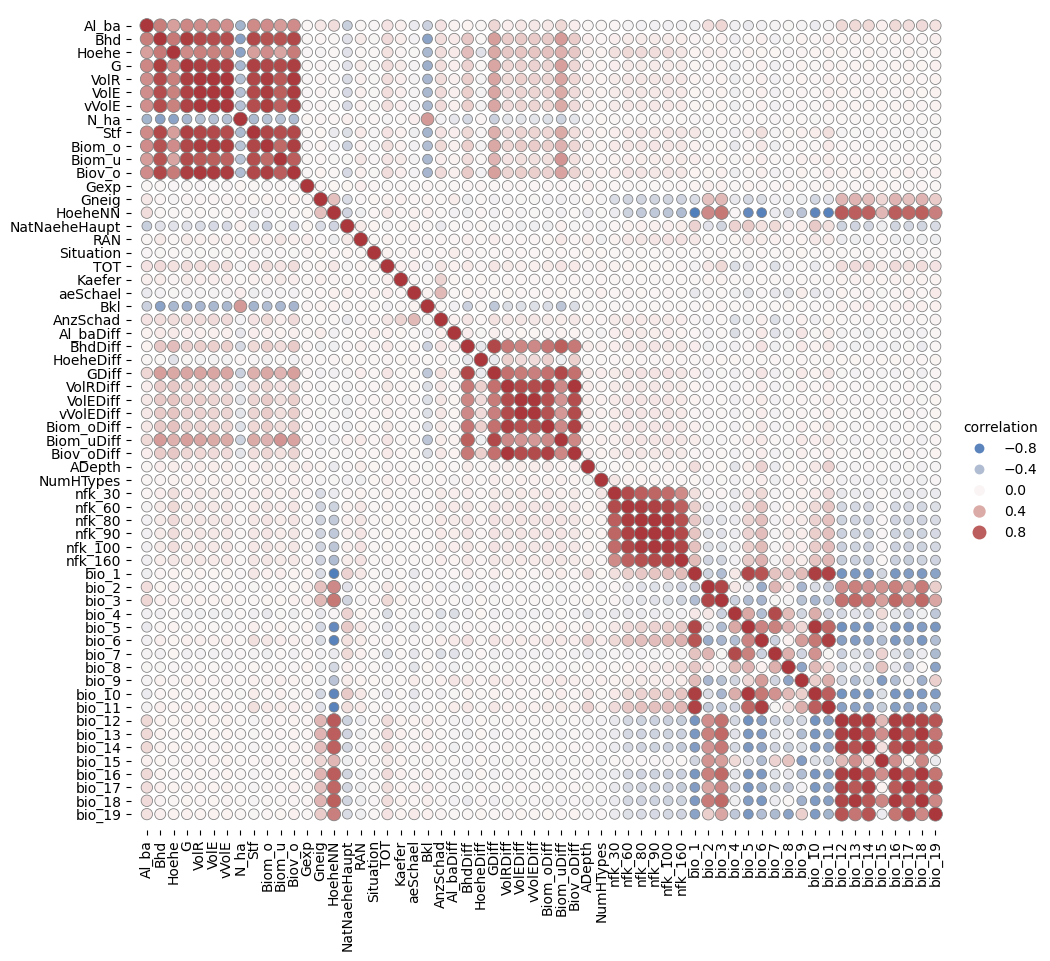

In [26]:
# Create a scatter plot with correlation data
g = sns.relplot(
    data=corr_mat,
    x="level_0", y="level_1", hue="correlation", size="correlation",
    palette="vlag", hue_norm=(-1, 1), edgecolor="0.5",
    height=10, sizes=(50, 100), size_norm=(-.2, .8),  # Reduced max size from 250 to 150
)

# Tweak the figure to finalize
g.set(xlabel="", ylabel="", aspect="equal")
g.despine(left=True, bottom=True)
g.ax.margins(.02)

# Rotate x-axis labels for better readability
for label in g.ax.get_xticklabels():
    label.set_rotation(90)

# Tweak the figure to finalize
g.set(xlabel="", ylabel="", aspect="equal")
g.despine(left=True, bottom=True)
g.ax.margins(.02)

# Rotate x-axis labels for better readability
for label in g.ax.get_xticklabels():
    label.set_rotation(90)

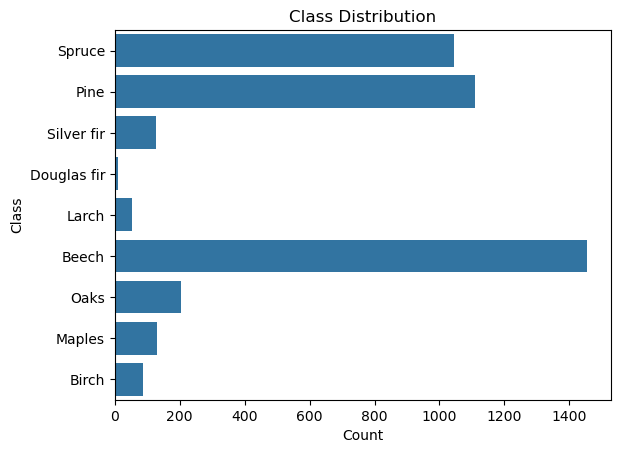

In [53]:
ticks_species = ['Spruce', 'Pine', 'Silver fir', 'Douglas fir', 'Larch', 'Beech', 'Oaks', 'Maples', 'Birch']
sns.countplot(y='Ba', data=data, orient='h')
plt.title('Class Distribution')
plt.xlabel('Count')
plt.ylabel('Class')
plt.yticks(ticks=range(len(ticks_species)), labels=ticks_species)
plt.show()

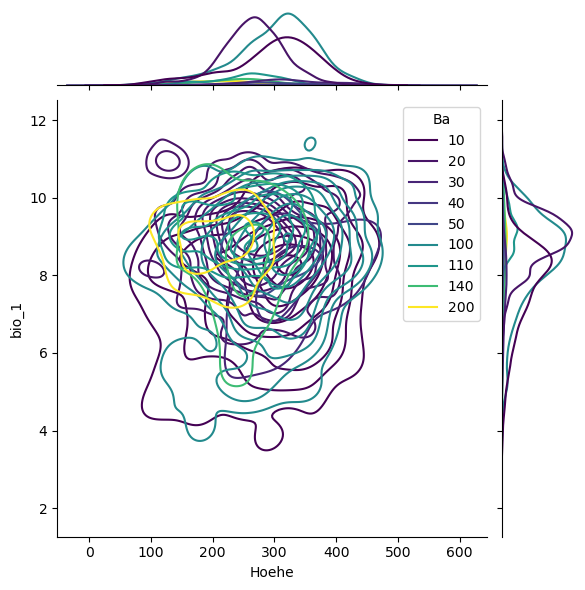

In [37]:
# Show the joint distribution using kernel density estimation
g = sns.jointplot(
    data=data,
    x="Hoehe", y="bio_1", hue="Ba",
    kind="kde",
    palette="viridis"  # You can choose any palette you prefer
)

In [46]:
data['bl'].value_counts()

bl
9     1773
8      661
7      332
16     291
6      256
3      234
13     169
14     150
15     147
12     122
5       62
1       14
11      13
Name: count, dtype: int64

In [52]:

features_continuous

,Al_ba,Bhd,Hoehe,G,VolR,VolE,vVolE,N_ha,Stf,Biom_o,...,bio_10,bio_11,bio_12,bio_13,bio_14,bio_15,bio_16,bio_17,bio_18,bio_19
35,94.0,423,281.0,0.140531,1.974456,1.688700,1.617737,36.621220,30.253450,929.590393,...,15.57,-1.75,1864,249,107,0.31,675,348,675,348
147,154.0,324,217.0,0.082448,1.094788,0.938544,0.880122,48.515450,29.707827,740.724670,...,13.89,-2.89,1390,192,77,0.34,522,238,522,238
149,154.0,299,212.0,0.070215,0.676227,0.514701,0.469247,56.967575,25.671076,507.055664,...,13.89,-2.89,1390,192,77,0.34,522,238,522,238
155,194.0,546,287.0,0.234140,2.196767,1.604715,1.457336,17.083815,48.507252,1078.656250,...,13.86,-2.95,1388,193,76,0.34,524,235,524,235
156,194.0,524,299.0,0.215651,2.668861,2.166502,2.054318,18.548447,44.902039,1294.437866,...,13.86,-2.95,1388,193,76,0.34,524,235,524,235
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189814,63.0,262,205.0,0.053913,0.608683,0.508806,0.481563,74.193787,13.363010,272.374817,...,14.86,-2.24,1044,110,52,0.19,311,221,305,253
189819,63.0,220,209.0,0.038013,0.349356,0.266408,0.239679,105.226410,10.262589,160.431686,...,14.86,-2.24,1044,110,52,0.19,311,221,305,253
189822,63.0,305,218.0,0.073062,0.827405,0.671828,0.634390,0.000000,17.097025,374.757416,...,14.86,-2.24,1044,110,52,0.19,311,221,305,253
189895,139.0,318,298.0,0.079423,1.103017,0.883885,0.837197,50.363499,18.337406,476.999664,...,15.26,-1.84,1172,125,57,0.19,348,247,343,287
